# 02 — Modelo de aluno: produção × diagnóstico

Este notebook não treina modelos — apenas lê os artefatos gravados por `python -m src.modeling.train` em `reports/` e `models/`. Essa separação mantém o treino reproduzível via script, isolado da análise exploratória dos resultados feita aqui.

In [10]:
import sys; sys.path.insert(0, "..")
import json
import numpy as np
import pandas as pd

from src import config
from src.evaluation import interpret, metrics
from src.modeling import predict
from src.preprocessing import features
from src.visualization import plots
from IPython.display import Image, display

pd.set_option("display.width", 160)
M = {n: json.loads((config.REPORTS / f"metricas_{n}.json").read_text(encoding="utf-8"))
     for n in ["producao_dummy", "producao_logistica", "producao_hgb", "diagnostico_hgb"]}  # já treinados por train.py, aqui só lê o json
base = pd.read_parquet(config.PROCESSED / "base_modelagem_aluno.parquet")

## 1. Conferindo vazamento no código

> **Para recordar — vazamento de dado (data leakage):** quando uma informação que não estaria disponível no momento real da previsão acaba entrando no treino, o desempenho medido fica artificialmente melhor do que seria no uso real. Por isso a lista de colunas proibidas é checada de forma automática no código, não só de olho.

In [11]:
num_p, cat_p = features.colunas_por_regime(base, "producao")
num_d, cat_d = features.colunas_por_regime(base, "diagnostico")
print(f"produção: {len(num_p)} numéricas + {cat_p}")
print(f"diagnóstico acrescenta: {sorted(set(num_d) - set(num_p))}")
print("proibidas:", sorted(config.COLUNAS_PROIBIDAS))
features.verificar_leakage(num_p + cat_p)   # levanta ValueError se algo proibido entrar

produção: 78 numéricas + ['rede_nome', 'sigla_uf', 'regiao']
diagnóstico acrescenta: ['n_alunos_escola', 'prof_media_escola_loo', 'taxa_escola_loo', 'taxa_participacao_escola_loo']
proibidas: ['_ingestion_ts', '_row_hash', '_source', 'alfabetizado', 'atingiu_meta', 'caderno', 'gap', 'id_aluno', 'id_escola', 'id_municipio', 'peso_aluno', 'preenchimento_caderno', 'presenca', 'presenca_nome', 'presente', 'proficiencia', 'sem_nota', 'serie', 'situacao_meta']


## 2. Comparando os modelos no teste (mesmas 6.350 escolas, que o treino nunca viu)

,roc_auc,pr_auc_nao_alf,recall_nao_alf,precisao_nao_alf,f1_nao_alf,balanced_accuracy,brier,roc_auc_pond,pr_auc_nao_alf_pond,limiar
producao_dummy,0.500,0.401,1.000,0.401,0.573,0.500,0.240,0.500,0.407,0.597
producao_logistica,0.662,0.549,0.801,0.473,0.595,0.602,0.222,0.659,0.552,0.650
producao_hgb,0.663,0.546,0.801,0.475,0.596,0.604,0.222,0.660,0.550,0.665
diagnostico_hgb,0.685,0.580,0.800,0.492,0.609,0.623,0.216,0.683,0.585,0.666


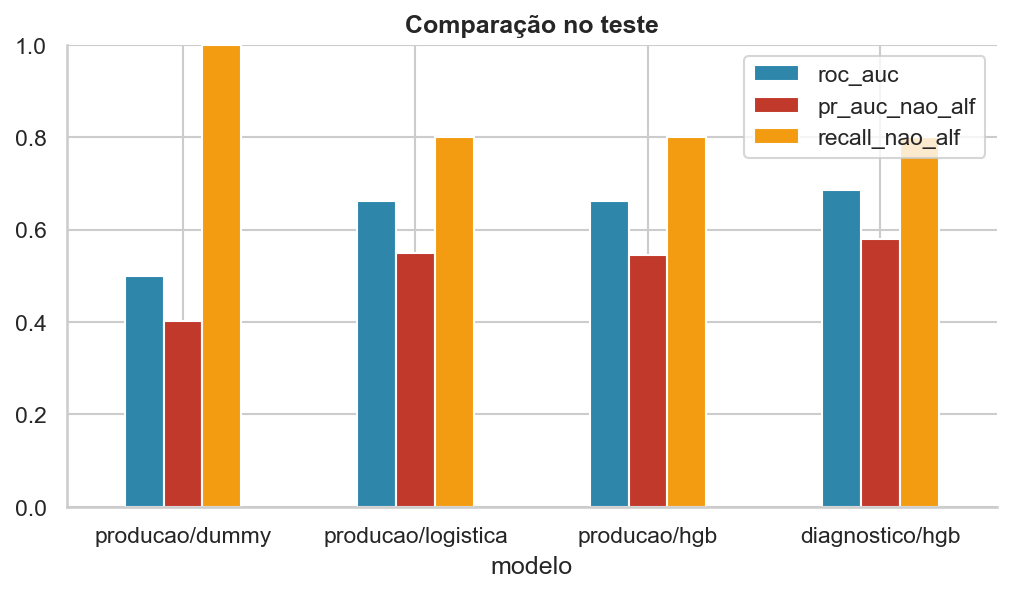

In [12]:
chaves = ["roc_auc", "pr_auc_nao_alf", "recall_nao_alf", "precisao_nao_alf", "f1_nao_alf", "balanced_accuracy", "brier"]
tab = pd.DataFrame({n: {**{k: m["teste"][k] for k in chaves}, **{f"{k}_pond": m["teste_ponderado"][k] for k in ["roc_auc", "pr_auc_nao_alf"]}, "limiar": m["limiar"]} for n, m in M.items()}).T  # _pond = mesma métrica só que ponderada por peso_aluno
display(tab.round(3))
caminho = plots.salvar(plots.plot_comparacao_modelos(list(M.values())), "modelos_comparacao")
display(Image(filename=str(caminho)))

Resultado notável: a regressão logística chega a um AUC quase igual ao do HGB (gradient boosting, ver nota abaixo). A diferença pequena entre um modelo linear e um baseado em árvores sugere que o sinal disponível nas features é majoritariamente linear — sobra pouca interação complexa para o HGB explorar. O regime diagnóstico (contexto da escola no mesmo ano) melhora o AUC só um pouco, o que combina com o que já tinha aparecido na Hipótese 09 do notebook 01: 75% da variação é dentro da própria escola, então mesmo com o contexto completo dela, o comportamento do aluno continua em grande parte imprevisível.

> **Para recordar:**
> - **ROC-AUC (ou só "AUC")**: mede o quanto o modelo separa bem as duas classes, testando todos os limiares de decisão possíveis. 0,5 = chute aleatório; 1,0 = separação perfeita.
> - **F1-score**: uma média entre recall e precisão, num único número — resume os dois de uma vez.
> - **Balanced accuracy**: a média do recall calculado separadamente em cada classe, para que a classe maior não "esconda" um desempenho ruim na classe menor.
> - **Brier score**: mede o erro entre a probabilidade que o modelo deu e o resultado real (0 ou 1) — quanto menor, mais confiável a probabilidade.
> - **Gradient boosting / HGB**: modelo que soma várias árvores de decisão treinadas em sequência, cada uma corrigindo o erro deixado pela anterior.

## 3. Curvas, calibração e escolhendo o limiar

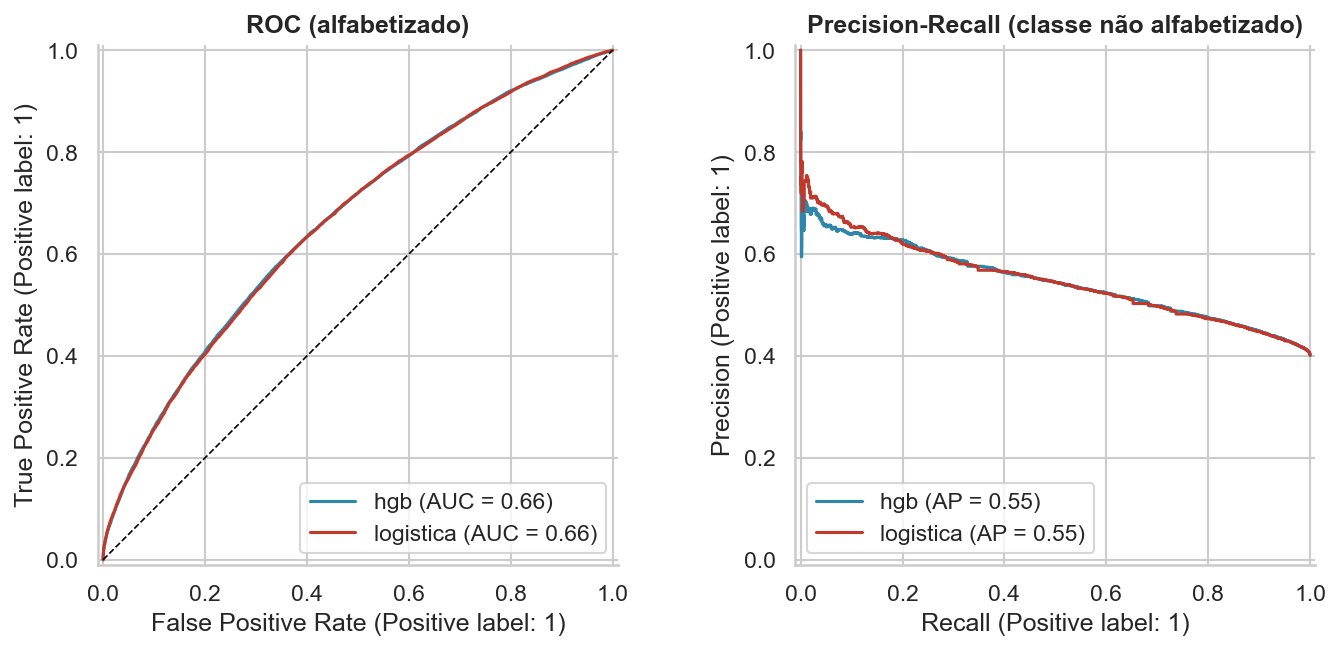

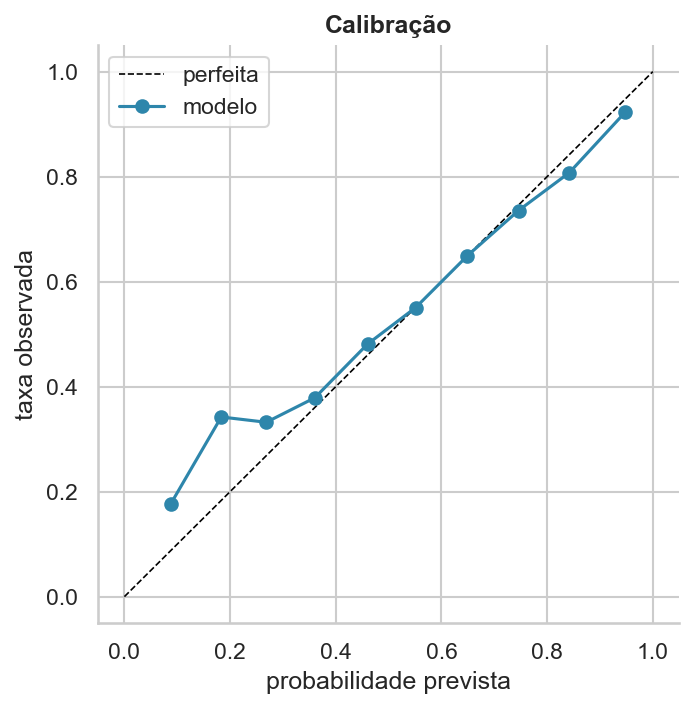

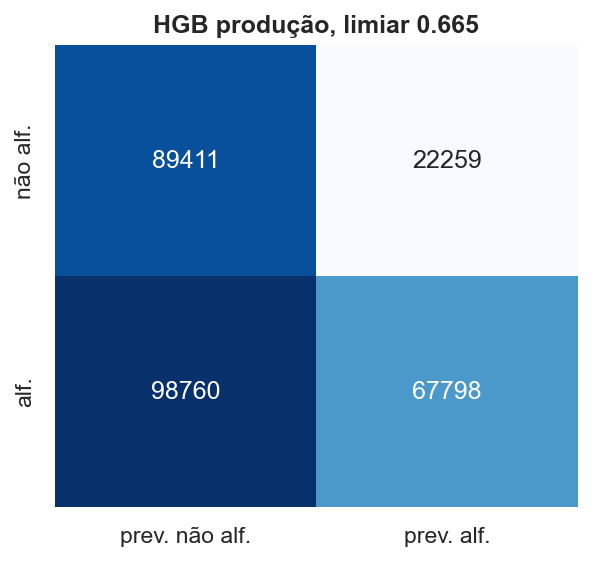

In [13]:
pred = {n: pd.read_csv(config.REPORTS / f"predicoes_producao_{n}.csv").merge(base[["id_aluno", "alfabetizado", "peso_aluno", "rede_nome", "regiao", "sem_historico"]], on="id_aluno")
        for n in ["hgb", "logistica"]}  # o csv de predição só tem id e probabilidade; junta de volta as colunas que preciso pra cortar por grupo mais abaixo
caminho = plots.salvar(plots.plot_roc_pr({n: (p["alfabetizado"], p["prob_alfabetizado"]) for n, p in pred.items()}), "roc_pr_modelos")
display(Image(filename=str(caminho)))
caminho = plots.salvar(plots.plot_calibracao(metrics.tabela_calibracao(pred["hgb"]["alfabetizado"], pred["hgb"]["prob_alfabetizado"])), "calibracao_producao")
display(Image(filename=str(caminho)))
caminho = plots.salvar(plots.plot_matriz_confusao(M["producao_hgb"]["teste"]["matriz"], f"HGB produção, limiar {M['producao_hgb']['limiar']:.3f}"), "matriz_confusao_producao")
display(Image(filename=str(caminho)))

**Como o limiar foi escolhido.** A escolha não foi pelo limiar que maximiza o F1, nem pelo ponto mais próximo do canto ideal da curva ROC — nenhum dos dois responde à pergunta certa para este problema. O critério foi prático: na validação, usar o menor limiar que ainda captura 80% dos casos "não alfabetizado" (recall alto de propósito, para não deixar passar criança em risco). O preço é a precisão, que cai para ≈ 0,48 — quase metade de quem o modelo aponta estaria, na verdade, alfabetizada. Para triagem de política pública, onde o custo de investigar um falso positivo é bem menor que o de ignorar um falso negativo, essa troca compensa. Para decidir sobre uma criança específica, não compensa — e essa limitação de uso fica registrada aqui.

> **Para recordar:**
> - **Limiar (threshold)**: o ponto de corte na probabilidade prevista a partir do qual o modelo classifica como "não alfabetizado". Mudar o limiar troca recall por precisão (ou vice-versa).
> - **Curva ROC**: gráfico que mostra, para cada limiar possível, a relação entre acertos e falsos alarmes — a área embaixo dela é o AUC.
> - **Calibração**: verifica se as probabilidades do modelo "batem" com a realidade — por exemplo, entre os casos em que o modelo disse "70% de chance", checar se de fato uns 70% eram da classe prevista.

## 4. Olhando por recorte: será que o modelo funciona igual em toda UF?

,recorte,n,prevalencia_nao_alf,roc_auc,recall_nao_alf,precisao_nao_alf
0,CE,12673,0.164,0.717,0.126,0.372
1,PI,4870,0.385,0.660,0.808,0.473
2,AL,3635,0.503,0.657,0.954,0.564
3,AP,1014,0.510,0.656,1.000,0.523
4,MA,9459,0.388,0.631,0.840,0.437
5,RJ,18137,0.442,0.628,0.935,0.453
6,GO,11172,0.265,0.628,0.379,0.381
7,PB,4844,0.434,0.620,0.923,0.470
8,SE,2755,0.617,0.611,0.959,0.639
9,PE,12048,0.383,0.610,0.807,0.438


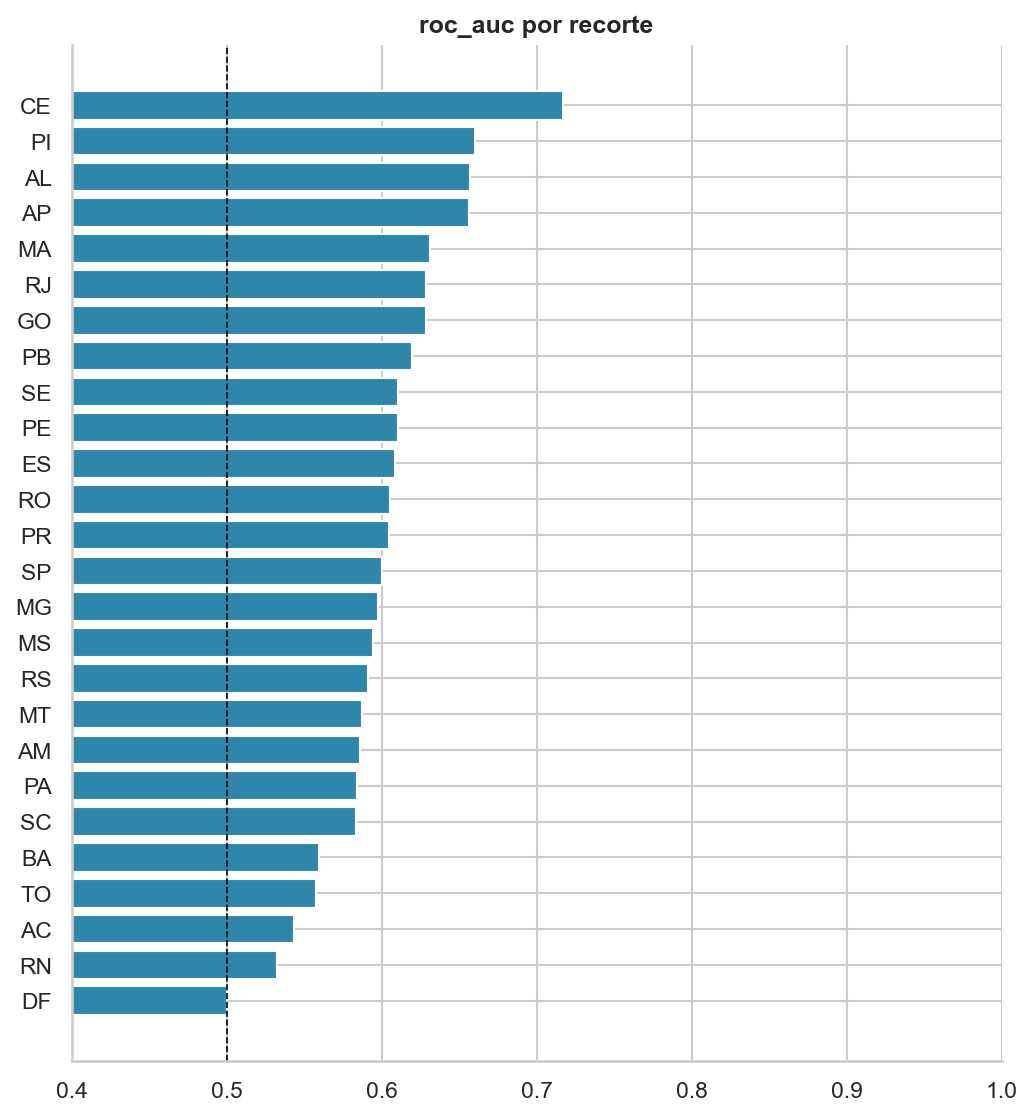

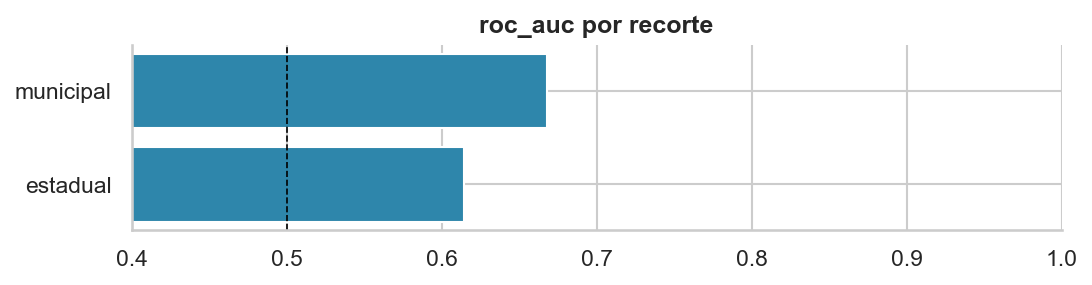

sem_historico=False: n=213,486 roc_auc=0.679 recall=0.767
sem_historico=True: n=64,742 roc_auc=0.596 recall=0.898


In [14]:
uf = pd.DataFrame(M["producao_hgb"]["por_uf"])
display(uf[["recorte", "n", "prevalencia_nao_alf", "roc_auc", "recall_nao_alf", "precisao_nao_alf"]].round(3))
caminho = plots.salvar(plots.plot_por_recorte(uf), "metricas_por_uf")
display(Image(filename=str(caminho)))
caminho = plots.salvar(plots.plot_por_recorte(pd.DataFrame(M["producao_hgb"]["por_rede"])), "metricas_por_rede")
display(Image(filename=str(caminho)))
p = pred["hgb"]
for nome, g in p.groupby("sem_historico"):  # confere separado quem caiu em município sem ano anterior (feature imputada) -- não pode ficar muito pior que o resto
    m = metrics.calcular_metricas(g["alfabetizado"], g["prob_alfabetizado"], M["producao_hgb"]["limiar"])
    print(f"sem_historico={nome}: n={m['n']:,} roc_auc={m['roc_auc']:.3f} recall={m['recall_nao_alf']:.3f}")

Dois casos de degradação identificados e documentados como limitação, em vez de omitidos. O **DF** apresenta AUC 0,50 — não é bug: o DF é um único município, então toda feature municipal é constante dentro dele, restando apenas `rede_nome` como fonte de variação. O modelo literalmente não tem sinal para diferenciar os alunos. O segundo caso é o **CE**: o recall cai para 0,13 com o limiar global, porque a prevalência de não-alfabetização ali é 16%, bem abaixo dos ~40% para os quais o limiar foi calibrado. Um limiar por UF resolveria esse desalinhamento de prevalência, mas fica registrado como próximo passo, fora do escopo desta entrega.

## 5. Abrindo a caixa: o que o modelo está usando de fato

> **Para recordar:**
> - **Permutation importance**: mede a importância de uma variável embaralhando seus valores (quebrando a relação dela com o alvo) e vendo o quanto o desempenho do modelo piora — quanto maior a queda, mais importante era a variável.
> - **SHAP**: para cada previsão individual, mostra o quanto cada variável empurrou o resultado para cima ou para baixo, permitindo entender o modelo caso a caso, não só no geral.

c:\Users\tcarm\Projetos\predicao-alfabetiza-brasil\.venv\Lib\site-packages\sklearn\impute\_base.py:598: UserWarning: Skipping features without any observed values: ['pct_va_agropecuaria' 'pct_va_industria' 'pct_va_servicos'
 'pct_va_adespss' 'projecao_ideb_ai']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,feature,importancia_media,importancia_dp
0,meta_alvo,0.0128,0.0007
1,sigla_uf,0.0120,0.0002
2,rede,0.0085,0.0003
3,taxa_limite_inferior_mun_t1,0.0067,0.0004
4,proficiencia_media_mun_t1,0.0051,0.0003
5,nota_saeb_mat_ai,0.0031,0.0002
6,ideb_ai,0.0015,0.0001
7,dsu_ai,0.0010,0.0002
8,nota_saeb_lp_ai,0.0009,0.0002
9,pct_nivel_7_mun_t1,0.0008,0.0002


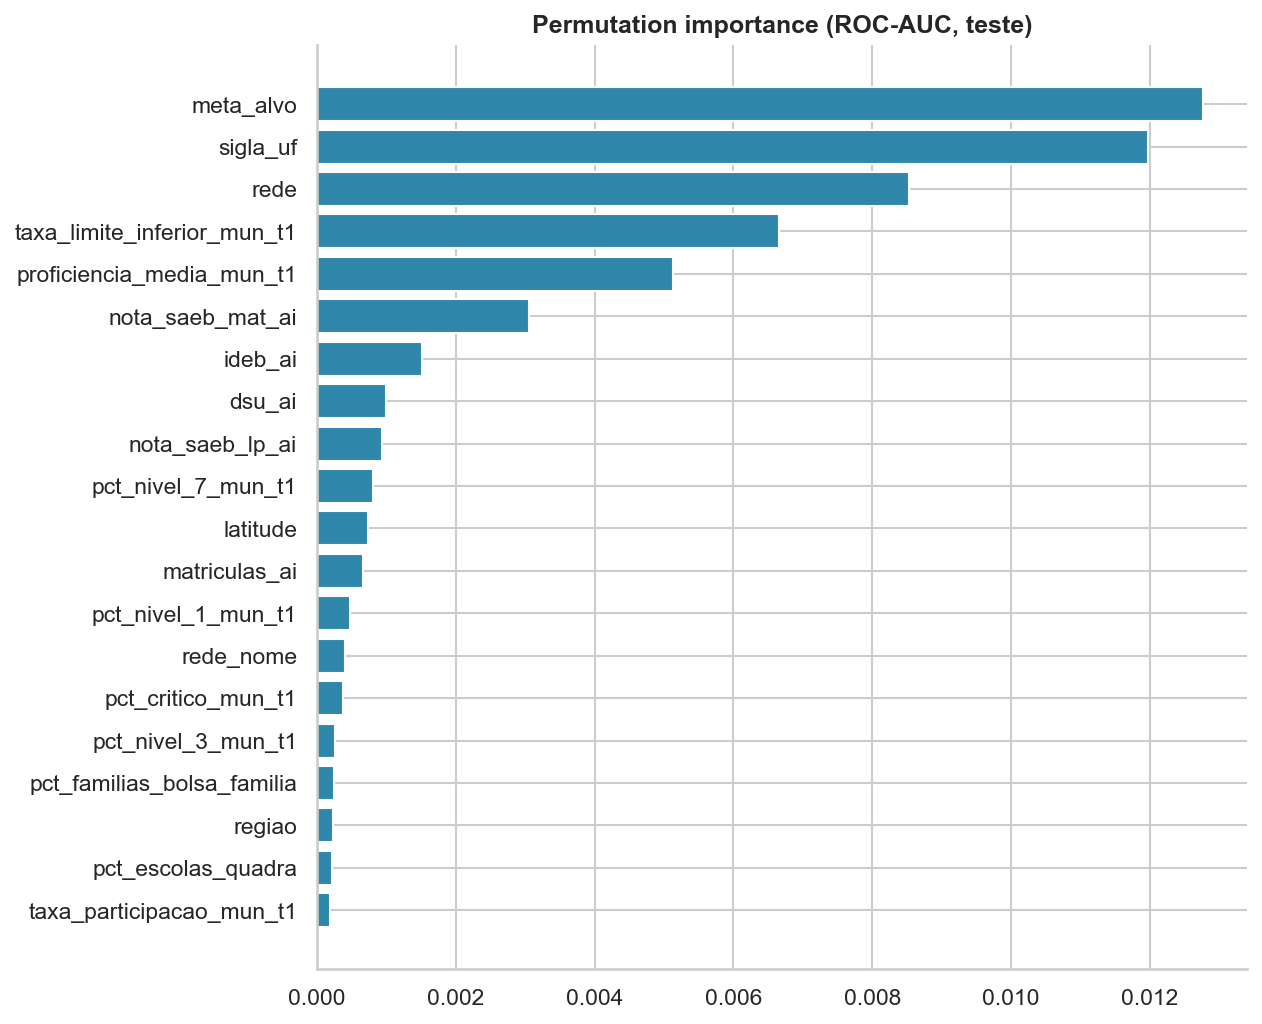

In [15]:
pipe = predict.carregar_modelo(regime="producao", modelo="hgb")
part = pd.read_parquet(config.MODELS / "particao_producao.parquet")
teste = base[base["id_aluno"].isin(part.loc[part["parte"] == "teste", "id_aluno"])].reset_index(drop=True)  # reconstrói o mesmo teste do treino a partir dos ids salvos na partição
X, y, _, pesos = features.separar_xy(teste, "producao")
imp = interpret.importancia_permutacao(pipe, X, y, pesos=pesos)
imp.to_csv(config.REPORTS / "importancia_permutacao_producao.csv", index=False)
display(imp.head(15).round(4))
caminho = plots.salvar(plots.plot_barras_horizontais(imp, "importancia_media", top=20, titulo="Permutation importance (ROC-AUC, teste)"), "importancia_permutacao_producao")
display(Image(filename=str(caminho)))

c:\Users\tcarm\Projetos\predicao-alfabetiza-brasil\.venv\Lib\site-packages\sklearn\impute\_base.py:598: UserWarning: Skipping features without any observed values: ['pct_va_agropecuaria' 'pct_va_industria' 'pct_va_servicos'
 'pct_va_adespss' 'projecao_ideb_ai']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,feature,shap_medio_abs
0,meta_alvo,0.1224
1,proficiencia_media_mun_t1,0.1200
2,taxa_limite_inferior_mun_t1,0.1113
3,rede,0.0606
4,nota_saeb_mat_ai,0.0508
5,ideb_ai,0.0466
6,sigla_uf_RS,0.0439
7,nota_saeb_lp_ai,0.0385
8,sigla_uf_MG,0.0382
9,latitude,0.0333


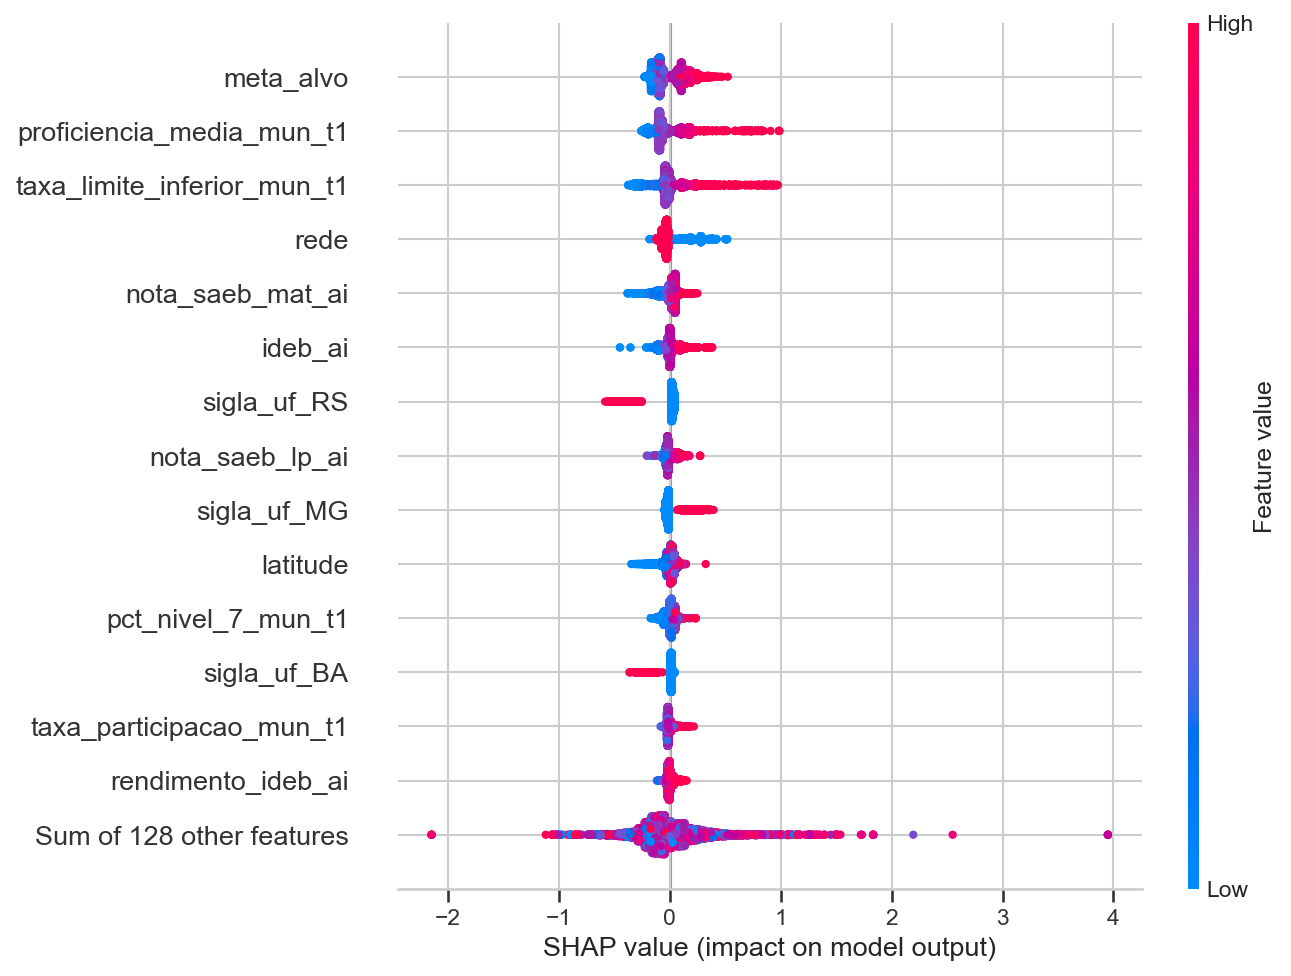

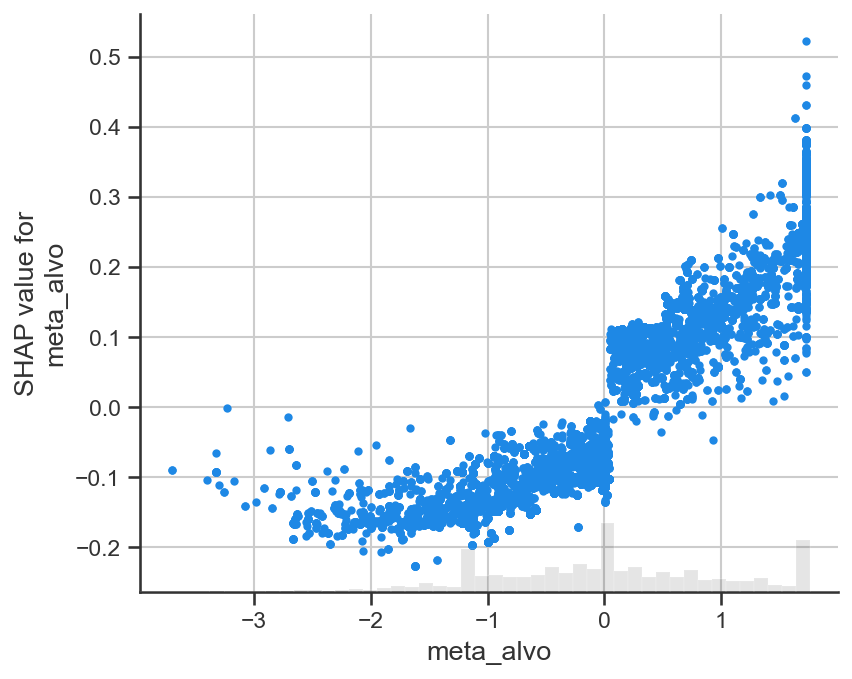

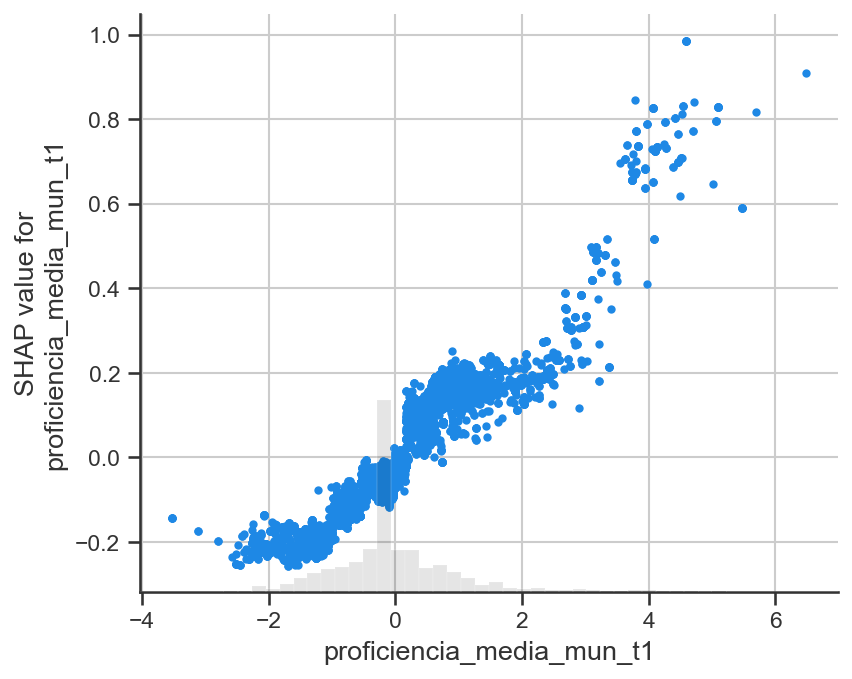

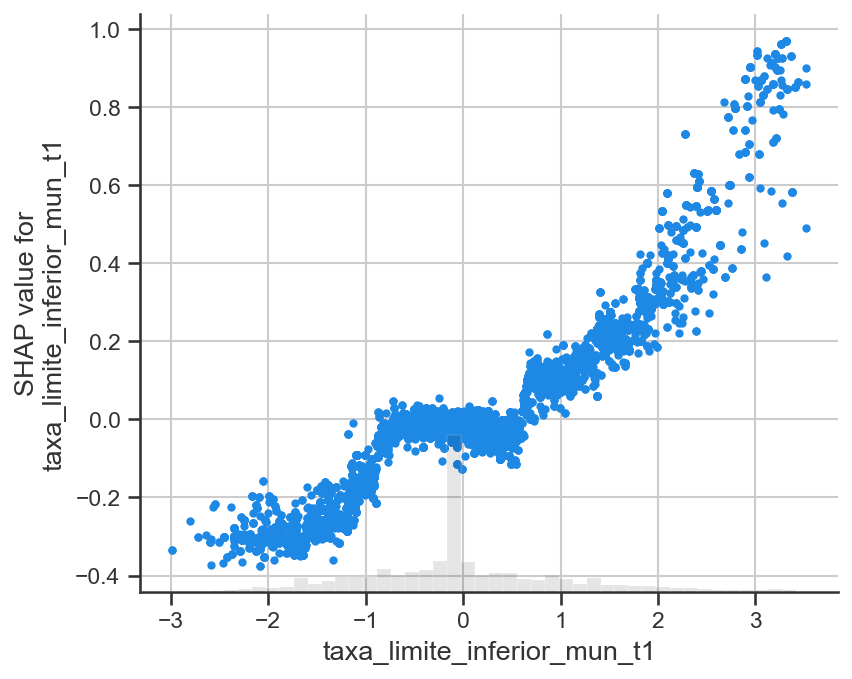

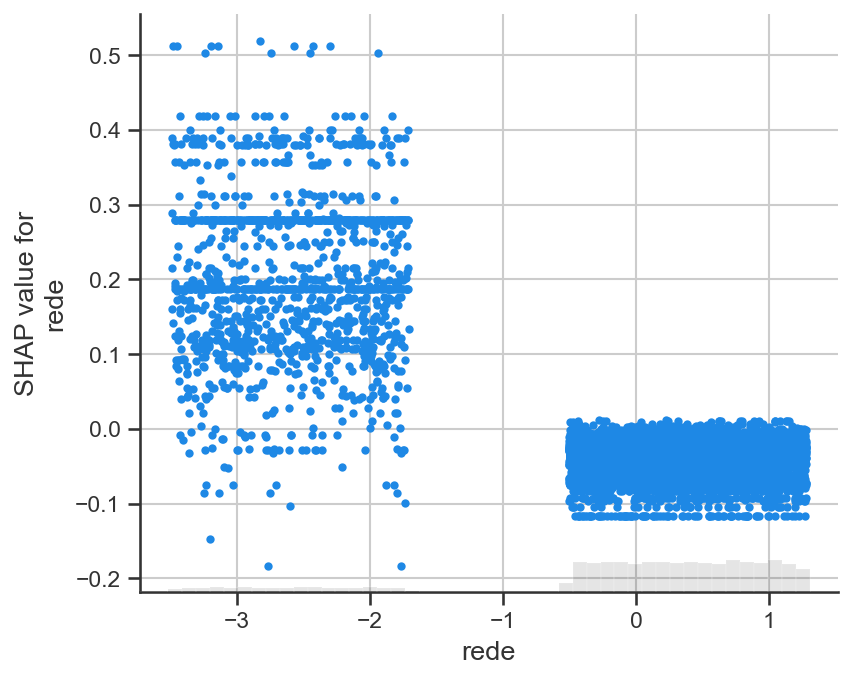

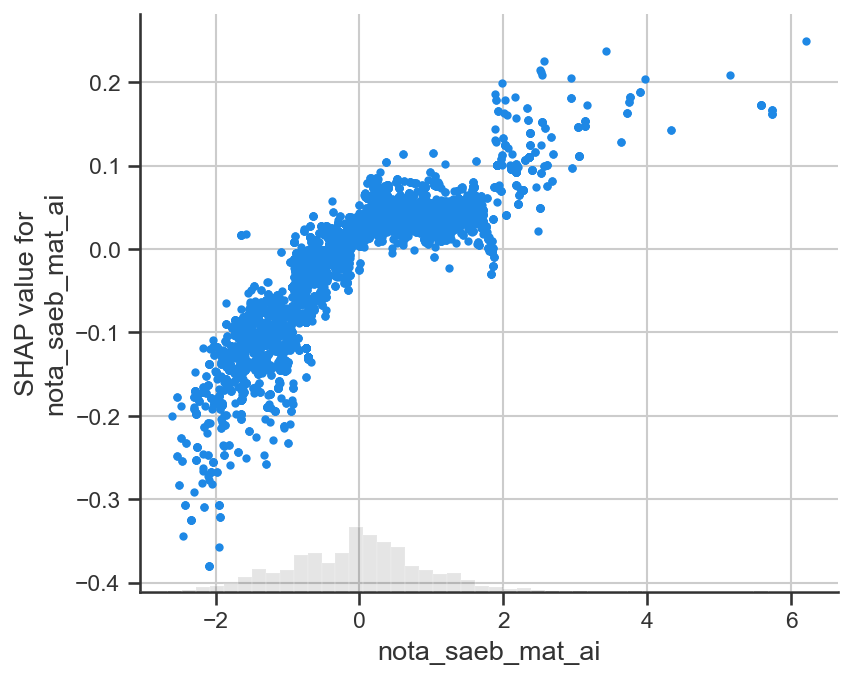

,meta_alvo,proficiencia_media_mun_t1,taxa_limite_inferior_mun_t1,rede,nota_saeb_mat_ai,ideb_ai,sigla_uf_RS,nota_saeb_lp_ai,sigla_uf_MG,latitude
Centro-Oeste,0.1296,0.1038,0.0956,0.0457,0.0429,0.0428,0.0283,0.0307,0.0196,0.0345
Nordeste,0.1486,0.1873,0.2232,0.0345,0.0640,0.0668,0.0220,0.0421,0.0165,0.0274
Norte,0.0961,0.1121,0.1080,0.0555,0.0731,0.0487,0.0230,0.0348,0.0176,0.0155
Sudeste,0.1123,0.0941,0.0512,0.0903,0.0427,0.0357,0.0238,0.0375,0.0687,0.0290
Sul,0.1218,0.0958,0.1004,0.0391,0.0384,0.0438,0.1592,0.0437,0.0218,0.0674


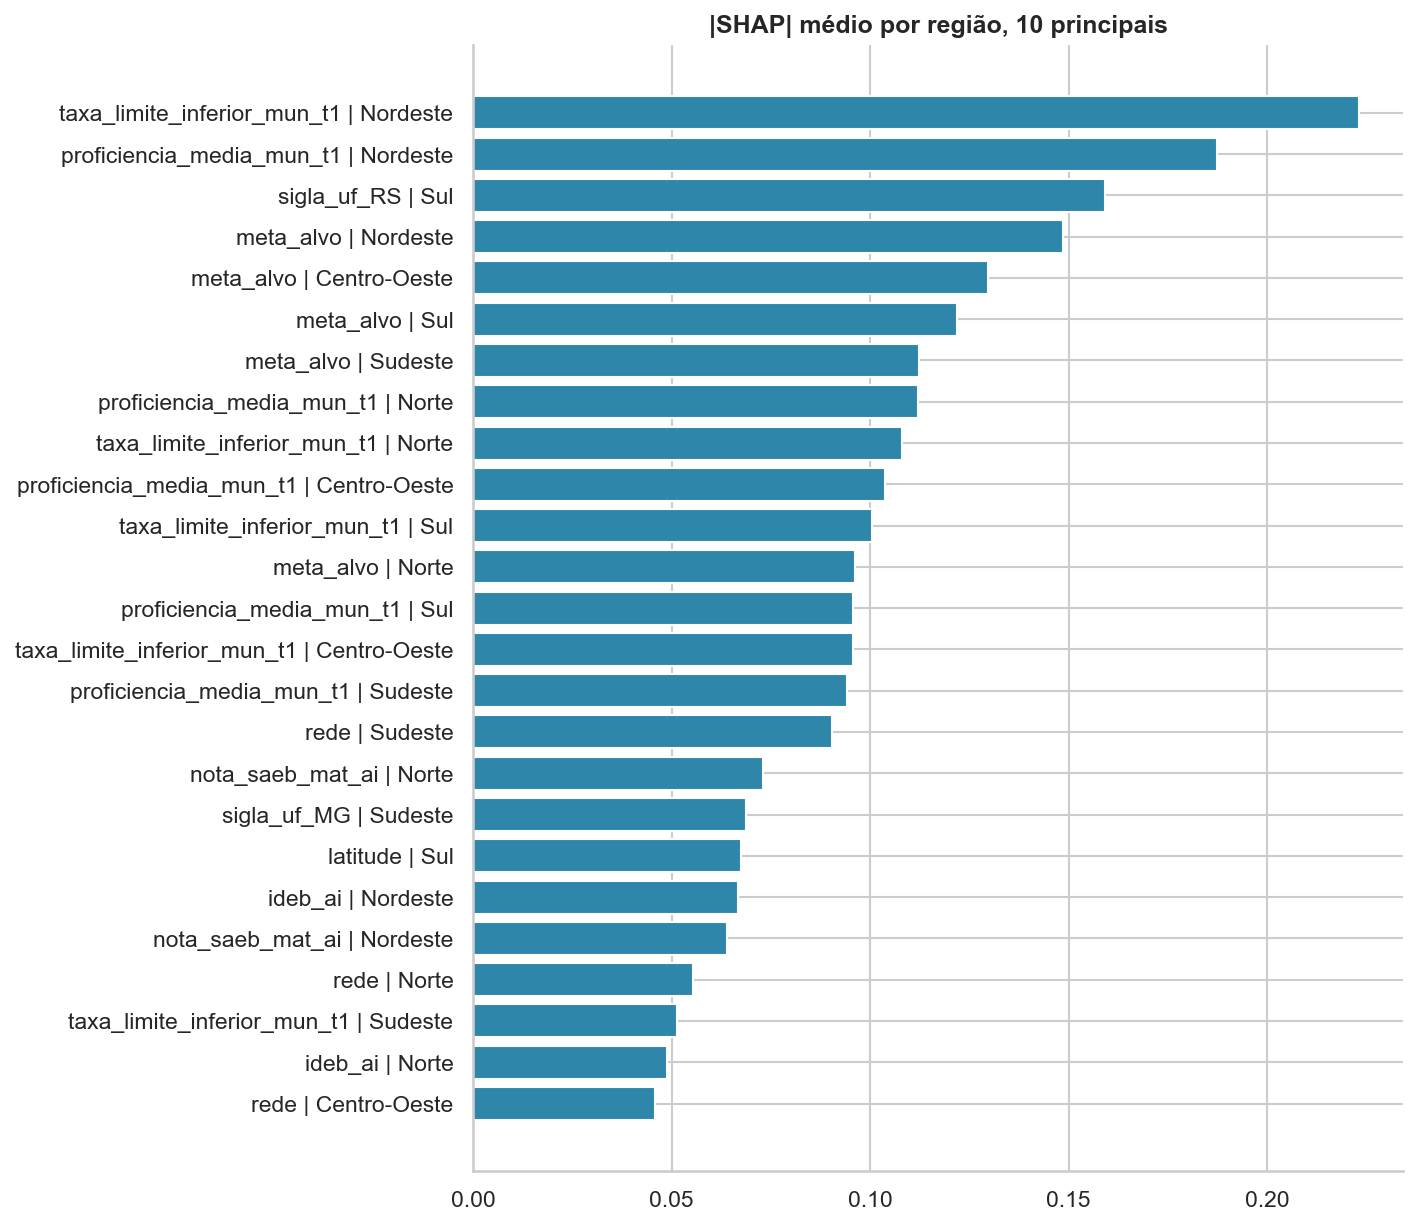

In [16]:
pos = interpret.amostrar_posicoes(len(X), 10_000)  # SHAP em cima do teste inteiro demora demais, roda numa amostra de 10k
exp = interpret.explicar_shap(pipe, X.iloc[pos], n_amostra=None)
res = interpret.resumo_shap(exp)
res.to_csv(config.REPORTS / "shap_resumo_producao.csv", index=False)
display(res.head(15).round(4))
caminho = plots.salvar(plots.plot_shap_beeswarm(exp, top=15), "shap_beeswarm_producao")
display(Image(filename=str(caminho)))
top5 = [f for f in res["feature"].head(8) if not f.startswith(("faltante_", "sigla_uf_", "regiao_", "rede_nome_"))][:5]  # tira indicador de faltante e dummy de categórica -- dependence plot só faz sentido pra variável numérica de verdade
for f in top5:
    caminho = plots.salvar(plots.plot_shap_dependence(exp, f), f"shap_dependence_{f}")
    display(Image(filename=str(caminho)))
por_regiao = interpret.shap_por_grupo(exp, teste["regiao"].iloc[pos].to_numpy())  # aqui dá pra ver o que ficou em aberto no notebook 01 (Hipótese 02/Hipótese 11): o efeito muda de sinal por região
display(por_regiao[res["feature"].head(10)].round(4))
caminho = plots.salvar(plots.plot_barras_horizontais(por_regiao[res["feature"].head(10)].T.reset_index().melt(id_vars="index", var_name="regiao", value_name="shap").rename(columns={"index": "feature"}).assign(feature=lambda d: d["feature"] + " | " + d["regiao"]), "shap", top=25, titulo="|SHAP| médio por região, 10 principais"), "shap_por_regiao")
display(Image(filename=str(caminho)))

In [17]:
coef = interpret.coeficientes_logistica(predict.carregar_modelo(regime="producao", modelo="logistica"))
display(coef.head(15).round(3))

,feature,coeficiente
0,sigla_uf_RS,-0.695
1,sigla_uf_CE,0.629
2,proficiencia_media_mun_t1,0.551
3,sigla_uf_BA,-0.448
4,matriculas_ai,-0.329
5,sigla_uf_GO,0.321
6,regiao_Sul,-0.320
7,sigla_uf_PR,0.264
8,sigla_uf_PE,0.245
9,regiao_Nordeste,0.222


## 6. O que o contexto da escola acrescenta (regime diagnóstico)

c:\Users\tcarm\Projetos\predicao-alfabetiza-brasil\.venv\Lib\site-packages\sklearn\impute\_base.py:598: UserWarning: Skipping features without any observed values: ['pct_va_agropecuaria' 'pct_va_industria' 'pct_va_servicos'
 'pct_va_adespss' 'projecao_ideb_ai']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,feature,shap_medio_abs
0,prof_media_escola_loo,0.4644
1,taxa_escola_loo,0.2266
2,n_alunos_escola,0.0431
3,taxa_participacao_escola_loo,0.0363
4,sigla_uf_SP,0.0253
5,nota_saeb_mat_ai,0.0224
6,pct_nivel_3_mun_t1,0.0209
7,pct_nivel_0_mun_t1,0.0208
8,nota_saeb_lp_ai,0.0208
9,sigla_uf_RS,0.0182


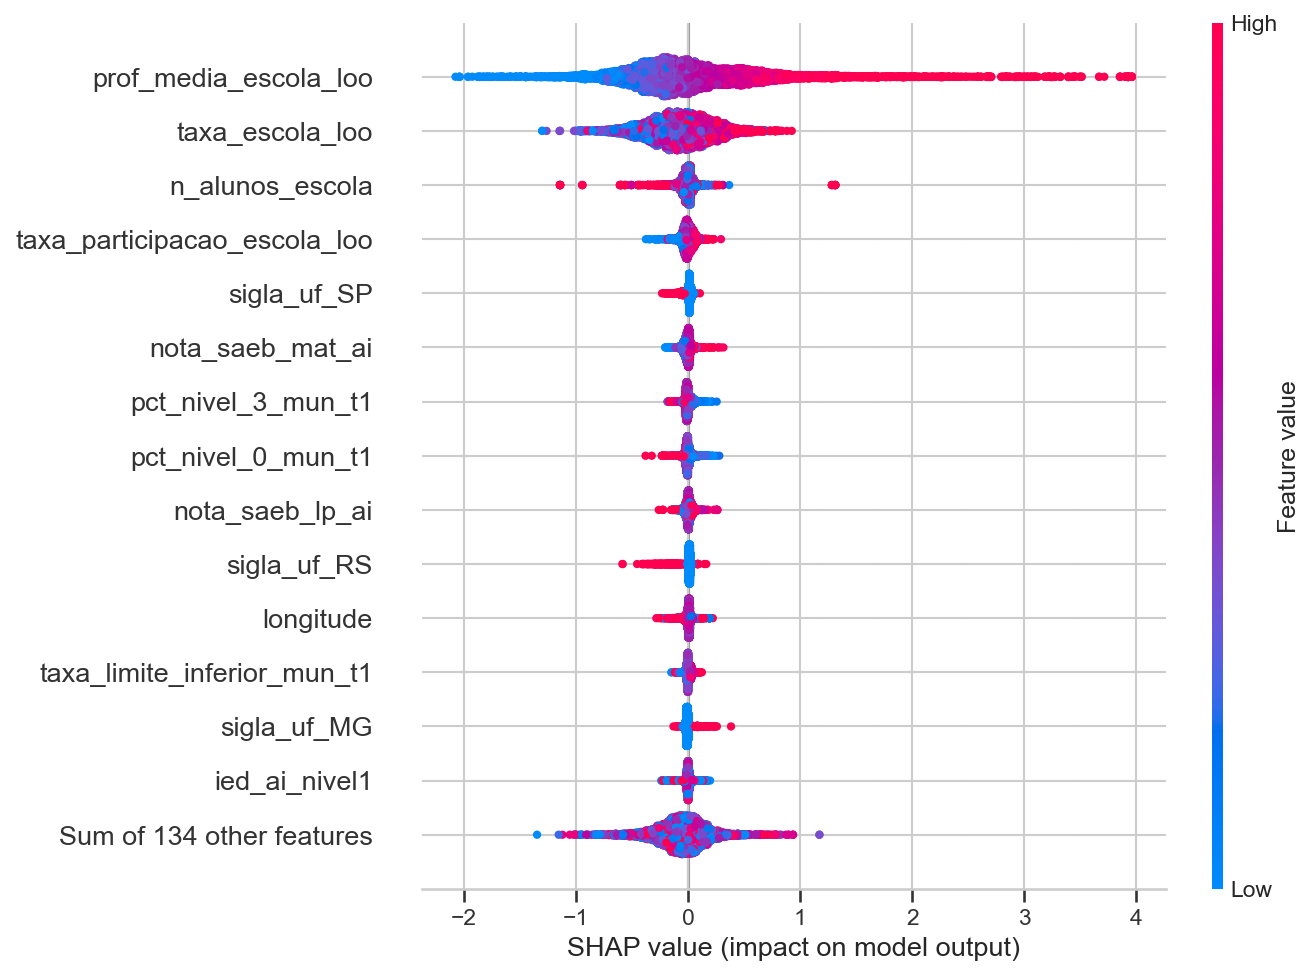

ganho de AUC produção → diagnóstico: +0.022


In [18]:
pipe_d = predict.carregar_modelo(regime="diagnostico", modelo="hgb")
part_d = pd.read_parquet(config.MODELS / "particao_diagnostico.parquet")  # partição própria do diagnóstico -- as features mudam, então não dá pra reusar a partição do produção
teste_d = base[base["id_aluno"].isin(part_d.loc[part_d["parte"] == "teste", "id_aluno"])].reset_index(drop=True)
Xd, yd, _, _ = features.separar_xy(teste_d, "diagnostico")
exp_d = interpret.explicar_shap(pipe_d, Xd, n_amostra=10_000)
display(interpret.resumo_shap(exp_d).head(10).round(4))
caminho = plots.salvar(plots.plot_shap_beeswarm(exp_d, top=15), "shap_beeswarm_diagnostico")
display(Image(filename=str(caminho)))
print(f"ganho de AUC produção → diagnóstico: {M['diagnostico_hgb']['teste']['roc_auc'] - M['producao_hgb']['teste']['roc_auc']:+.3f}")  # sobe pouco -- bate com a Hipótese 09: mesmo sabendo da escola, o aluno individual continua imprevisível

## 7. Escopo do modelo: o que ele responde e o que não responde

Esse ponto é registrado explicitamente porque a leitura "modelo prevê alfabetização" é facilmente mal interpretada.

O que o modelo responde: *dado o contexto em que a criança estuda (o município no ano anterior, a rede, o território, o perfil socioeconômico), qual a probabilidade de ela estar alfabetizada?* É uma ferramenta de priorização de contextos — quais municípios, quais redes merecem mais atenção — não de rotulagem de indivíduos.

O que o modelo não responde: *essa criança específica vai se alfabetizar?* A base não contém nenhum atributo individual do aluno — idade, histórico, características pessoais —, então o teto de previsibilidade é limitado ao que o contexto explica. Como mostrado na Hipótese 09, 75% da variância é intra-escola, não entre escolas; mesmo o regime diagnóstico, que incorpora o contexto da própria escola no mesmo ano, não altera substancialmente esse teto. O contexto explica apenas uma parcela do resultado, e é exatamente essa parcela que o modelo capta.